## Model Evaluation - Decision Tree

### Import Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE


### Load Dataset

In [9]:
df = pd.read_csv("cleaned_customer_financial_behaviour.csv")

print(df.head())
print(df["default_12m"].value_counts())

   age  gender  employment_status  annual_income  monthly_income  loan_amount  \
0   42       1                  1        83834.0         6986.17      50000.0   
1   35       0                  0        56472.0         4706.00      50000.0   
2   44       1                  0       165696.0        13808.00      50000.0   
3   41       0                  0        79943.0         6661.92      50000.0   
4   28       0                  0       160442.0        13370.17      52071.0   

   interest_rate  loan_term      emi   dti  credit_score_origination  \
0          12.33         36  1668.61  0.35                       720   
1          10.98         48  1291.79  0.41                       658   
2           9.71         84   822.59  0.44                       801   
3          14.42         36  1719.10  0.38                       743   
4          10.81         36  1700.06  0.10                       662   

   revolving_utilization_origination  credit_inquiries_12m  \
0                 

### Feature and Target

In [10]:
X = df.drop("default_12m", axis=1)
y = df["default_12m"]

### Split dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Apply SMOTE to trainig data

In [12]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
default_12m
0    99705
1     8295
Name: count, dtype: int64

After SMOTE:
default_12m
0    99705
1    99705
Name: count, dtype: int64


### Train Random Forest

In [13]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_res, y_train_res)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Predict

In [14]:
y_pred_rf = rf.predict(X_test)

### Evaluate

In [15]:
print("\n===== Random Forest =====")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


===== Random Forest =====
Accuracy : 0.831037037037037
Precision: 0.08338914936369725
Recall   : 0.12005785920925748
F1 Score : 0.09841897233201581

Confusion Matrix:
[[22189  2737]
 [ 1825   249]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.91     24926
           1       0.08      0.12      0.10      2074

    accuracy                           0.83     27000
   macro avg       0.50      0.51      0.50     27000
weighted avg       0.86      0.83      0.84     27000



### Store Result

In [16]:
results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, y_pred_rf),
        "Precision": precision_score(y_test, y_pred_rf),
        "Recall": recall_score(y_test, y_pred_rf),
        "F1-score": f1_score(y_test, y_pred_rf)
    }
])

print("\nResults:")
print(results)



Results:
           Model  Accuracy  Precision    Recall  F1-score
0  Random Forest  0.831037   0.083389  0.120058  0.098419


### Plot Results

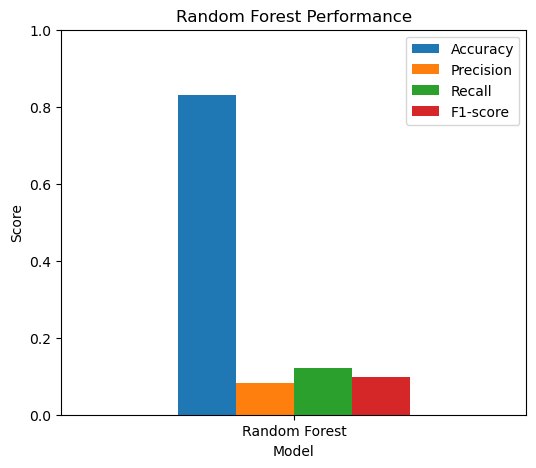

In [17]:
results.set_index("Model").plot(kind="bar", figsize=(6,5))
plt.title("Random Forest Performance")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.ylabel("Score")
plt.show()